# LSTM Character-Level Text Generation

> **Generative AI with LSTM** — Interview Task

Train a character-level LSTM on Shakespeare's Complete Works and generate new text.

---

**Table of Contents**
1. [Setup & Imports](#setup)
2. [Dataset Download & Exploration](#dataset)
3. [Text Preprocessing](#preprocessing)
4. [Vocabulary & Sequence Creation](#vocab)
5. [Model Architecture](#model)
6. [Model Training](#training)
7. [Text Generation](#generation)
8. [BONUS: Architecture Comparison](#bonus)


## 1. Setup & Imports <a id='setup'></a>

Install and import all required libraries.

In [4]:
# Uncomment to install if needed:
# !pip install tensorflow numpy matplotlib seaborn requests tqdm

import os, re, pickle, warnings
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import callbacks as keras_callbacks

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.19.0
NumPy      : 2.4.6
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
# ── GPU Check ──────────────────────────────────────────────────────────────
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f'  GPU: {gpu.name}')
    print('GPU memory growth enabled -- training will be fast!')
else:
    print('No GPU found! Go to: Settings (right panel) > Accelerator > GPU T4 x2')


GPUs available: 2
  GPU: /physical_device:GPU:0
  GPU: /physical_device:GPU:1
GPU memory growth enabled -- training will be fast!


### Configuration

All hyperparameters in one place — edit here to experiment.

In [ ]:
# ─── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
DATA_DIR    = os.path.join(BASE_DIR, "data")
MODELS_DIR  = os.path.join(BASE_DIR, "models", "checkpoints")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
for d in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

DATA_PATH   = os.path.join(DATA_DIR,    "shakespeare.txt")
VOCAB_PATH  = os.path.join(OUTPUTS_DIR, "vocab.pkl")
OUTPUT_TEXT = os.path.join(OUTPUTS_DIR, "generated_samples.txt")

# ─── Preprocessing ─────────────────────────────────────────────────────────────
SEQ_LENGTH   = 100   
STEP_SIZE    = 3     
TRAIN_SPLIT  = 0.80  

# ─── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE      = 512   
EPOCHS          = 30    
LEARNING_RATE   = 0.001
EARLY_PATIENCE  = 5
LR_PATIENCE     = 3

# ─── Generation ────────────────────────────────────────────────────────────────
GENERATE_LENGTH = 500
TEMPERATURES    = [0.2, 0.8, 1.2]

# ─── Dataset ───────────────────────────────────────────────────────────────────
DATASET_URL = "https://www.gutenberg.org/files/100/100-0.txt"

SAMPLE_SEEDS = [
    "to be or not to be that is the question whether tis nobler in the mind to suffer",
    "shall i compare thee to a summers day thou art more lovely and more temperate",
    "all the worlds a stage and all the men and women merely players they have their",
    "friends romans countrymen lend me your ears i come to bury caesar not to praise",
]

print("Configuration loaded successfully.")


Configuration loaded successfully.


In [7]:
def download_shakespeare(url=DATASET_URL, save_path=DATA_PATH):
    """Download or load cached Shakespeare corpus."""
    if os.path.exists(save_path):
        print(f"Loading cached corpus from: {save_path}")
        with open(save_path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    print("Downloading from Project Gutenberg...")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with open(save_path, "w", encoding="utf-8") as f:
        f.write(r.text)
    print(f"Downloaded and cached to: {save_path}")
    return r.text


raw_text = download_shakespeare()

n_chars = len(raw_text)
n_lines = len(raw_text.splitlines())
n_words = len(raw_text.split())
n_uniq  = len(set(raw_text))

print(f"\nDataset Statistics")
print(f"  Characters (raw) : {n_chars:,}")
print(f"  Lines            : {n_lines:,}")
print(f"  Words            : {n_words:,}")
print(f"  Unique chars     : {n_uniq}")
print(f"\nFirst 500 characters:\n{'─'*60}")
print(raw_text[:500])


Downloaded and cached to: /kaggle/working/data/shakespeare.txt

Dataset Statistics
  Characters (raw) : 5,359,444
  Lines            : 196,022
  Words            : 963,478
  Unique chars     : 100

First 500 characters:
────────────────────────────────────────────────────────────
*** START OF THE PROJECT GUTENBERG EBOOK 100 ***




The Complete Works of William Shakespeare

by William Shakespeare




                    Contents

    THE SONNETS
    ALL’S WELL THAT ENDS WELL
    THE TRAGEDY OF ANTONY AND CLEOPATRA
    AS YOU LIKE IT
    THE COMEDY OF ERRORS
    THE TRAGEDY OF CORIOLANUS
    CYMBELINE
    THE TRAGEDY OF HAMLET, PRINCE OF DENMARK
    THE FIRST PART OF KING HENRY THE FOURTH
    THE SECOND PART OF KING HENRY THE FOURTH
    THE LIFE OF KING HENRY THE FIFTH
  


## 3. Text Preprocessing <a id='preprocessing'></a>

Raw Gutenberg text needs normalisation before modelling.



In [8]:
def clean_text(text):
    """
    Normalise raw corpus for character-level LSTM training.

    Steps:
    ------
    1. Strip Project Gutenberg header/footer
    2. Convert to lowercase
    3. Remove punctuation (keep a-z, 0-9, newline, space)
    4. Collapse whitespace
    """
    # Step 1 — strip boilerplate
    s = text.find("*** START OF")
    e = text.find("*** END OF")
    if s != -1:
        text = text[text.find("\n", s) + 1:]
    if e != -1:
        text = text[:e]

    # Step 2 — lowercase
    text = text.lower()

    # Step 3 — remove punctuation
    text = re.sub(r"[^a-z0-9\n ]", "", text)

    # Step 4 — collapse whitespace
    text = re.sub(r"[ \t]+", " ",  text)
    text = re.sub(r"\n+",   "\n", text)

    return text.strip()


clean = clean_text(raw_text)

before = len(raw_text)
after  = len(clean)
print(f"Before cleaning : {before:,} characters")
print(f"After  cleaning : {after:,} characters")
print(f"Reduction       : {(1 - after/before)*100:.1f}%")
print(f"\nCleaned sample:\n{'─'*60}")
print(clean[:600])


Before cleaning : 5,359,444 characters
After  cleaning : 5,027,493 characters
Reduction       : 6.2%

Cleaned sample:
────────────────────────────────────────────────────────────
the complete works of william shakespeare
by william shakespeare
 contents
 the sonnets
 alls well that ends well
 the tragedy of antony and cleopatra
 as you like it
 the comedy of errors
 the tragedy of coriolanus
 cymbeline
 the tragedy of hamlet prince of denmark
 the first part of king henry the fourth
 the second part of king henry the fourth
 the life of king henry the fifth
 the first part of henry the sixth
 the second part of king henry the sixth
 the third part of king henry the sixth
 king henry the eighth
 the life and death of king john
 the tragedy of julius caesar
 the tragedy 


## 4. Vocabulary Building & Sequence Creation <a id='vocab'></a>



In [9]:
# ─── Build Vocabulary ──────────────────────────────────────────────────────────
vocab    = sorted(set(clean))
char2idx = {ch: i for i, ch in enumerate(vocab)}
idx2char = {i: ch for i, ch in enumerate(vocab)}
VOCAB_SIZE = len(vocab)

print(f"Vocabulary size : {VOCAB_SIZE} unique characters")
print(f"Characters      : {repr(''.join(vocab))}")

# Persist vocabulary for standalone generate.py
with open(VOCAB_PATH, "wb") as f:
    pickle.dump({"char2idx": char2idx, "idx2char": idx2char, "vocab": vocab}, f)
print(f"\nVocabulary saved to: {VOCAB_PATH}")


Vocabulary size : 38 unique characters
Characters      : '\n 0123456789abcdefghijklmnopqrstuvwxyz'

Vocabulary saved to: /kaggle/working/outputs/vocab.pkl


In [10]:
# ─── Create Sequences ─────────────────────────────────────────────────────────
def create_sequences(text, char2idx, seq_length=SEQ_LENGTH, step=STEP_SIZE):
    """
    Build overlapping (input, target) pairs using a sliding window.

    Parameters
    ----------
    text      : Cleaned corpus string
    char2idx  : Character to index mapping
    seq_length: Window / input length
    step      : Stride between windows

    Returns
    -------
    X : ndarray (n_samples, seq_length) — integer char indices
    y : ndarray (n_samples,)             — integer target index
    """
    encoded = np.array([char2idx[ch] for ch in text], dtype=np.int32)
    starts  = list(range(0, len(encoded) - seq_length, step))

    X = np.stack([encoded[i : i+seq_length] for i in
                  tqdm(starts, desc="Building sequences")])
    y = np.array([encoded[i+seq_length] for i in starts], dtype=np.int32)
    return X, y


X, y = create_sequences(clean, char2idx)
print(f"\nX shape: {X.shape}  (samples x seq_length)")
print(f"y shape: {y.shape}  (samples,)")
print(f"\nExample pair:")
print(f"  Input  → {''.join(idx2char[i] for i in X[0][:60])}...")
print(f"  Target → '{idx2char[y[0]]}'")


Building sequences:   0%|          | 0/1675798 [00:00<?, ?it/s]


X shape: (1675798, 100)  (samples x seq_length)
y shape: (1675798,)  (samples,)

Example pair:
  Input  → the complete works of william shakespeare
by william shakesp...
  Target → 'h'


Training samples   : 1,340,638
Validation samples : 335,160


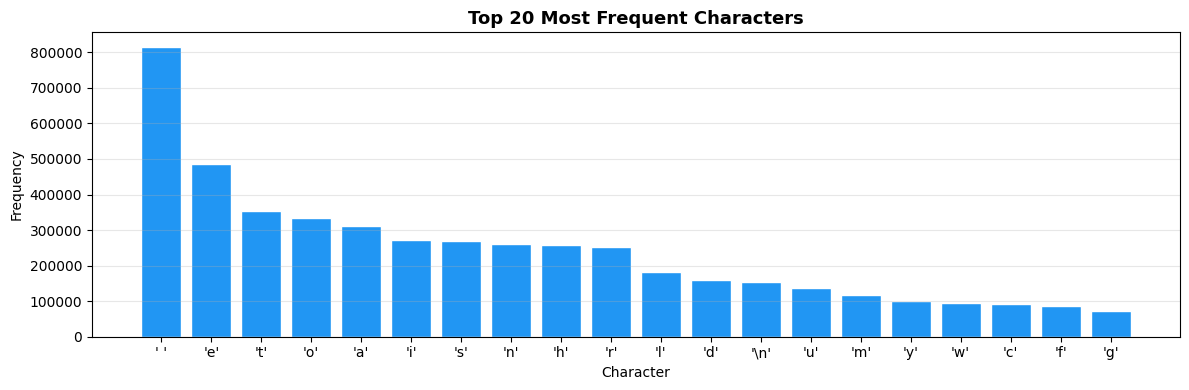

In [11]:
# ─── Train / Validation Split ─────────────────────────────────────────────────
n       = len(X)
rng     = np.random.default_rng(SEED)
indices = np.arange(n)
rng.shuffle(indices)

split   = int(n * TRAIN_SPLIT)
X_train, X_val = X[indices[:split]], X[indices[split:]]
y_train, y_val = y[indices[:split]], y[indices[split:]]

print(f"Training samples   : {len(X_train):,}")
print(f"Validation samples : {len(X_val):,}")

# ─── Character Frequency Plot ─────────────────────────────────────────────────
freq    = {ch: clean.count(ch) for ch in vocab}
top20   = sorted(freq, key=freq.get, reverse=True)[:20]
top_f   = [freq[c] for c in top20]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar([repr(c) for c in top20], top_f, color="#2196F3", edgecolor="white")
ax.set_title("Top 20 Most Frequent Characters", fontsize=13, fontweight="bold")
ax.set_xlabel("Character"); ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "char_frequency.png"), dpi=150)
plt.show()


## 5. Model Architecture <a id='model'></a>

```
Input (SEQ_LENGTH=100 integer indices)
   ↓
Embedding Layer  (vocab_size → embed_dim)
   ↓
LSTM Layer(s)    (configurable — see table below)
   ↓
Dropout          (prevents overfitting)
   ↓
Dense + Softmax  (outputs probability over each character)
```

| Architecture | LSTM Layers | Units | Dropout | Est. Params |
|---|---|---|---|---|
| **Baseline** | 1 | 256 | 30% | ~400K |
| **Deep** | 2 | 512 → 256 | 30% | ~1.5M |
| **Wide** | 1 | 1024 | 35% | ~1.4M |

**Loss:** SparseCategoricalCrossentropy (integer targets, no one-hot encoding needed)  
**Optimizer:** Adam with adaptive learning rate


In [12]:
ARCHITECTURE_CONFIGS = {
    "baseline": {"lstm_units": [256],      "dropout_rate": 0.30},
    "deep"    : {"lstm_units": [512, 256], "dropout_rate": 0.30},
    "wide"    : {"lstm_units": [1024],     "dropout_rate": 0.35},
}


def build_model(vocab_size, architecture="baseline",
                seq_length=SEQ_LENGTH, lr=LEARNING_RATE):
    """
    Build and compile an LSTM character-level text generation model.

    Architecture details:
    ─────────────────────
    • Embedding     : Learns a dense vector for each character
    • LSTM layer(s) : Captures sequential dependencies
                      (return_sequences=True for all but the last LSTM)
    • Dropout       : Regularisation — randomly zero activations during training
    • Dense+softmax : Projects to vocab_size and normalises to probabilities

    Compiled with:
    • Loss      : SparseCategoricalCrossentropy
    • Optimizer : Adam (lr=0.001 default)
    • Metric    : Accuracy
    """
    cfg   = ARCHITECTURE_CONFIGS[architecture]
    units = cfg["lstm_units"]
    drop  = cfg["dropout_rate"]
    embed = min(128, int(vocab_size**0.5) * 4)

    inp = tf.keras.Input(shape=(seq_length,), name="char_indices")
    x   = layers.Embedding(vocab_size, embed, name="embedding")(inp)

    for i, n in enumerate(units):
        ret_seq = (i < len(units) - 1)   # True for all layers except last
        x = layers.LSTM(n, return_sequences=ret_seq, name=f"lstm_{i+1}")(x)
        x = layers.Dropout(drop, name=f"dropout_{i+1}")(x)

    out = layers.Dense(vocab_size, activation="softmax", name="predictions")(x)

    m = tf.keras.Model(inp, out, name=f"lstm_{architecture}")
    m.compile(
        loss      = tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer = tf.keras.optimizers.Adam(lr),
        metrics   = ["accuracy"]
    )
    return m


# Build primary model and display summary
model = build_model(VOCAB_SIZE, architecture="baseline")
model.summary()


I0000 00:00:1781551635.136622      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781551635.142447      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "lstm_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ char_indices (InputLayer)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 24)        │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       287,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,422 (1.14 MB)

 Trainable params: 298,422 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training <a id='training'></a>

**Callbacks used:**

| Callback | Purpose |
|---|---|
| `ModelCheckpoint` | Saves weights whenever `val_loss` improves |
| `EarlyStopping` | Stops after 5 epochs with no improvement |
| `ReduceLROnPlateau` | Halves LR after 3 stagnant epochs |
| `CSVLogger` | Logs metrics per epoch to CSV |


In [13]:
CKPT_PATH = os.path.join(MODELS_DIR, "best_model_baseline.weights.h5")
CSV_LOG   = os.path.join(OUTPUTS_DIR, "training_log.csv")

training_callbacks = [
    keras_callbacks.ModelCheckpoint(
        CKPT_PATH, monitor="val_loss",
        save_best_only=True, save_weights_only=True, verbose=1
    ),
    keras_callbacks.EarlyStopping(
        monitor="val_loss", patience=EARLY_PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras_callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=LR_PATIENCE,
        min_lr=1e-6, verbose=1
    ),
    keras_callbacks.CSVLogger(CSV_LOG, append=False),
]

print("Starting training...")
print(f"  Architecture : baseline")
print(f"  Max epochs   : {EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Checkpoint   : {CKPT_PATH}\n")

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = training_callbacks,
    verbose         = 1
)


Starting training...
  Architecture : baseline
  Max epochs   : 30
  Batch size   : 512
  Checkpoint   : /kaggle/working/models/checkpoints/best_model_baseline.weights.h5

Epoch 1/30


I0000 00:00:1781551639.426280     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


2618/2619 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3127 - loss: 2.3210
Epoch 1: val_loss improved from None to 1.72424, saving model to /kaggle/working/models/checkpoints/best_model_baseline.weights.h5

Epoch 1: finished saving model to /kaggle/working/models/checkpoints/best_model_baseline.weights.h5
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 121s 45ms/step - accuracy: 0.3789 - loss: 2.0532 - val_accuracy: 0.4652 - val_loss: 1.7242 - learning_rate: 0.0010
Epoch 2/30
2618/2619 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4632 - loss: 1.7339
Epoch 2: val_loss improved from 1.72424 to 1.56299, saving model to /kaggle/working/models/checkpoints/best_model_baseline.weights.h5

Epoch 2: finished saving model to /kaggle/working/models/checkpoints/best_model_baseline.weights.h5
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 126s 48ms/step - accuracy: 0.4750 - loss: 1.6927 - val_accuracy: 0.5123 - val_loss: 1.5630 - learning_rate: 0.0010
Epoch 3/30
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5002 

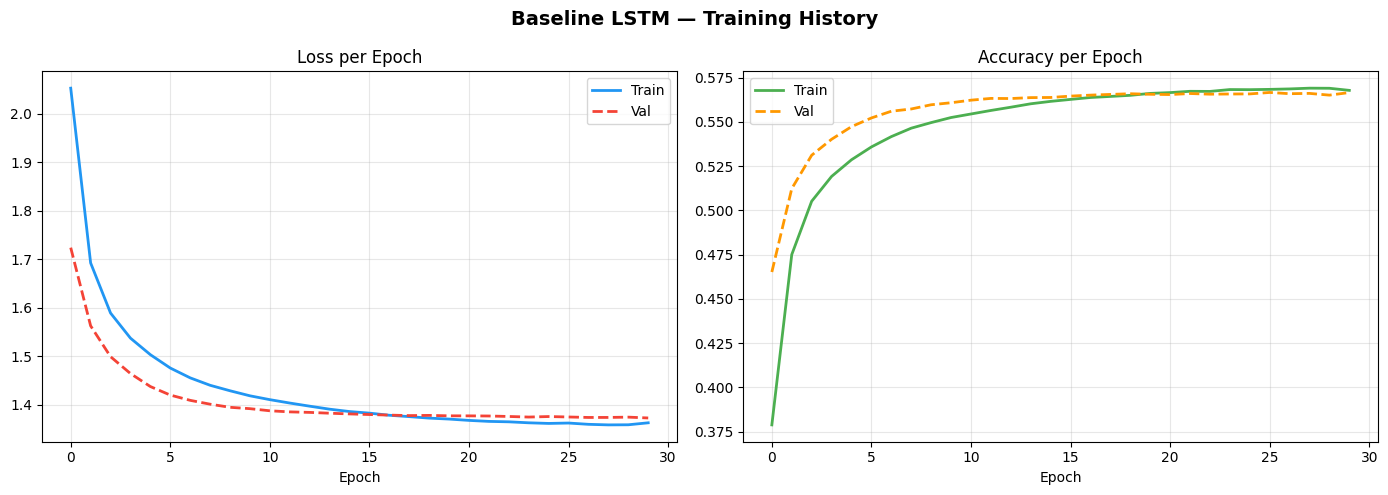

Final Val Loss     : 1.3730
Final Val Accuracy : 56.65%
Perplexity         : 3.95


In [14]:
# ─── Plot Training Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline LSTM — Training History", fontsize=14, fontweight="bold")

axes[0].plot(history.history["loss"],     label="Train", color="#2196F3", lw=2)
axes[0].plot(history.history["val_loss"], label="Val",   color="#F44336", lw=2, ls="--")
axes[0].set_title("Loss per Epoch"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"],     label="Train", color="#4CAF50", lw=2)
axes[1].plot(history.history["val_accuracy"], label="Val",   color="#FF9800", lw=2, ls="--")
axes[1].set_title("Accuracy per Epoch"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "training_history_baseline.png"), dpi=150)
plt.show()

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Final Val Loss     : {val_loss:.4f}")
print(f"Final Val Accuracy : {val_acc*100:.2f}%")
print(f"Perplexity         : {np.exp(val_loss):.2f}")


## 7. Text Generation <a id='generation'></a>




In [15]:
def sample_with_temperature(preds, temperature=1.0):
    """
    Sample from model output probabilities using temperature scaling.

    How temperature works:
    ─────────────────────
    The model outputs a softmax probability vector. We scale it:
      1. Take log probabilities
      2. Divide by temperature (> 1 flattens, < 1 sharpens)
      3. Re-normalise and sample

    Parameters
    ----------
    preds       : ndarray of shape (vocab_size,) — model output probs
    temperature : float > 0

    Returns
    -------
    int : sampled character index
    """
    preds = preds.astype(np.float64)
    log_p = np.log(preds + 1e-8) / temperature
    log_p -= log_p.max()           # numerical stability
    exp_p  = np.exp(log_p)
    p      = exp_p / exp_p.sum()
    return int(np.random.choice(len(p), p=p))


def generate_text(model, seed, char2idx, idx2char,
                  length=GENERATE_LENGTH, temperature=0.8,
                  seq_length=SEQ_LENGTH):
    """
    Generate new text from a seed string using a trained LSTM model.

    Parameters
    ----------
    model       : Trained tf.keras.Model
    seed        : Starting text string
    char2idx    : Character to index mapping
    idx2char    : Index to character mapping
    length      : Number of new characters to generate
    temperature : Sampling temperature
    seq_length  : Input window length (must match training)

    Returns
    -------
    str : seed + newly generated text
    """
    # Clean seed using same pipeline as training
    seed = seed.lower()
    seed = re.sub(r"[^a-z0-9\n ]", "", seed)
    seed = re.sub(r"[ \t]+", " ", seed).strip()

    # Pad (left) or trim (right) to seq_length
    if len(seed) < seq_length:
        seed = " " * (seq_length - len(seed)) + seed
    elif len(seed) > seq_length:
        seed = seed[-seq_length:]

    # Handle any OOV chars
    seed = "".join(c if c in char2idx else " " for c in seed)

    window    = list(seed)
    generated = list(seed)

    for _ in range(length):
        enc   = np.array([[char2idx[c] for c in window]])
        preds = model.predict(enc, verbose=0)[0]
        idx   = sample_with_temperature(preds, temperature)
        ch    = idx2char[idx]
        generated.append(ch)
        window.append(ch)
        window.pop(0)

    return "".join(generated)


In [16]:
# Generate text for all seeds and temperatures
all_results = []

for si, seed in enumerate(SAMPLE_SEEDS, 1):
    print(f"\nSeed {si}: \"{seed[:65]}...\"")
    print("─" * 65)
    for temp in TEMPERATURES:
        gen = generate_text(model, seed, char2idx, idx2char,
                            length=GENERATE_LENGTH, temperature=temp)
        all_results.append({"seed": seed, "temperature": temp, "text": gen})
        # Print only the newly generated portion (skip seed)
        preview = gen[SEQ_LENGTH : SEQ_LENGTH + 160]
        print(f"  temp={temp:.1f}: {preview}...")
        print()



Seed 1: "to be or not to be that is the question whether tis nobler in the..."
─────────────────────────────────────────────────────────────────
  temp=0.2:  the court
the court of the sea and see the court to the constant and the strain
that she is the gods and the last that the course
and see the death of the stat...

  temp=0.8:  the crown
how all fortune fastysempred with her this the soul
 exit in my way into the camp but caesar
and no poison to degionn boy of other death
that shall m...

  temp=1.2: 
my ring lews start
petty to tell doth her out as
thusterd outing edmund
 your woldsill
yet on fear ausut iques dome
that urje i for followering tongue so serva...


Seed 2: "shall i compare thee to a summers day thou art more lovely and mo..."
─────────────────────────────────────────────────────────────────
  temp=0.2: 
the life the castle which i shall be so fair
that i will not see the sea and there there is a service
the sea of this thing that the sea with the street
and th...



In [17]:
# Save all generated text to file
SEP = "=" * 70 + "\n"
with open(OUTPUT_TEXT, "w", encoding="utf-8") as f:
    f.write("LSTM TEXT GENERATION - SAMPLE OUTPUTS\n")
    f.write(SEP)
    f.write("Dataset: Shakespeare's Complete Works\n")
    f.write("Source : https://www.gutenberg.org/ebooks/100\n")
    f.write("License: Public Domain\n")
    f.write(SEP + "\n")
    for i, r in enumerate(all_results, 1):
        f.write(f"SAMPLE {i}\n")
        f.write(f"Seed        : \"{r['seed'][:80]}\"\n")
        f.write(f"Temperature : {r['temperature']}\n\n")
        f.write(r["text"] + "\n\n" + SEP + "\n")

print(f"Saved {len(all_results)} samples to: {OUTPUT_TEXT}")


Saved 12 samples to: /kaggle/working/outputs/generated_samples.txt


## 8. BONUS: Architecture Comparison <a id='bonus'></a>



In [18]:
BONUS_EPOCHS = 10   # 10 epochs per architecture on GPU
BONUS_BATCH  = 512  # Large batch for GPU efficiency
COMPARISON   = {}

for arch in ["baseline", "deep", "wide"]:
    print(f"Training: {arch}...")
    m  = build_model(VOCAB_SIZE, architecture=arch)
    ck = os.path.join(MODELS_DIR, f"best_model_{arch}.weights.h5")
    cb = [
        keras_callbacks.ModelCheckpoint(ck, monitor="val_loss",
            save_best_only=True, save_weights_only=True, verbose=0),
        keras_callbacks.EarlyStopping(monitor="val_loss", patience=3,
            restore_best_weights=True, verbose=0),
        keras_callbacks.ReduceLROnPlateau(monitor="val_loss",
            factor=0.5, patience=2, verbose=0),
    ]
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=BONUS_EPOCHS, batch_size=BONUS_BATCH,
              callbacks=cb, verbose=0)

    vl, va = m.evaluate(X_val, y_val, verbose=0)
    COMPARISON[arch] = {
        "history": h.history, "val_loss": vl,
        "val_acc": va, "perplexity": np.exp(vl),
        "params": m.count_params(), "model": m
    }
    print(f"  val_loss={vl:.4f}  val_acc={va*100:.1f}%  "
          f"perplexity={np.exp(vl):.2f}  params={m.count_params():,}")

print("\nDone!")


Training: baseline...


KeyboardInterrupt: 

In [19]:
# ─── Results Table ─────────────────────────────────────────────────────────────
print(f"{'Architecture':<12} {'Val Loss':>10} {'Val Acc':>10} {'Perplexity':>12} {'Params':>12}")
print("-" * 58)
for arch, r in COMPARISON.items():
    print(f"{arch:<12} {r['val_loss']:>10.4f} "
          f"{r['val_acc']*100:>9.1f}% "
          f"{r['perplexity']:>12.2f} "
          f"{r['params']:>12,}")


Architecture   Val Loss    Val Acc   Perplexity       Params
----------------------------------------------------------


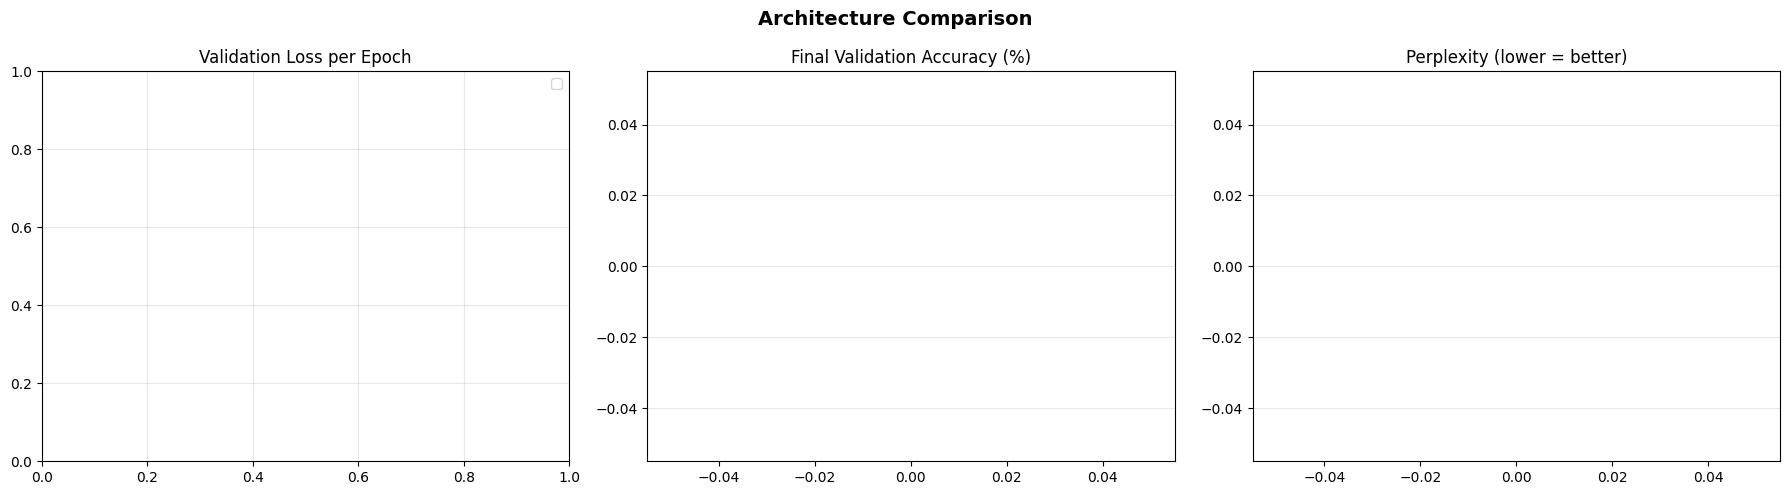

In [20]:
# ─── Comparison Plots ──────────────────────────────────────────────────────────
colors = {"baseline": "#2196F3", "deep": "#F44336", "wide": "#4CAF50"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Architecture Comparison", fontsize=14, fontweight="bold")

# Val Loss curves
for arch, r in COMPARISON.items():
    axes[0].plot(r["history"]["val_loss"], label=arch.capitalize(),
                 color=colors[arch], lw=2)
axes[0].set_title("Validation Loss per Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy bars
archs = list(COMPARISON)
accs  = [COMPARISON[a]["val_acc"] * 100 for a in archs]
bars  = axes[1].bar(archs, accs, color=[colors[a] for a in archs], edgecolor="white")
for b, a in zip(bars, accs):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
                 f"{a:.1f}%", ha="center", fontsize=10)
axes[1].set_title("Final Validation Accuracy (%)")
axes[1].grid(axis="y", alpha=0.3)

# Perplexity bars
perps = [COMPARISON[a]["perplexity"] for a in archs]
bars  = axes[2].bar(archs, perps, color=[colors[a] for a in archs], edgecolor="white")
for b, p in zip(bars, perps):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
                 f"{p:.1f}", ha="center", fontsize=10)
axes[2].set_title("Perplexity (lower = better)")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "architecture_comparison.png"), dpi=150)
plt.show()


In [21]:
# ─── Text samples from each architecture ───────────────────────────────────────
BONUS_SEED = SAMPLE_SEEDS[0]
BONUS_TEMP = 0.8
bonus_path = os.path.join(OUTPUTS_DIR, "bonus_architecture_comparison.txt")

with open(bonus_path, "w", encoding="utf-8") as f:
    f.write("BONUS: Architecture Comparison — Generated Text\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Seed : \"{BONUS_SEED}\"\n")
    f.write(f"Temp : {BONUS_TEMP}\n")
    f.write(f"Epochs: {BONUS_EPOCHS}\n\n")

    for arch, r in COMPARISON.items():
        gen = generate_text(r["model"], BONUS_SEED, char2idx, idx2char,
                            length=300, temperature=BONUS_TEMP)
        print(f"\n{arch.upper()} (perplexity={r['perplexity']:.2f}):")
        print(gen[SEQ_LENGTH : SEQ_LENGTH + 200])
        f.write(f"--- {arch.upper()} (perplexity={r['perplexity']:.2f}, params={r['params']:,}) ---\n")
        f.write(gen + "\n\n")

print(f"\nBonus comparison saved to: {bonus_path}")



Bonus comparison saved to: /kaggle/working/outputs/bonus_architecture_comparison.txt


## Summary

| Item | Details |
|---|---|
| **Dataset** | Shakespeare's Complete Works — [Project Gutenberg](https://www.gutenberg.org/ebooks/100) |
| **Tokenisation** | Character-level (unique chars = vocab items) |
| **Sequences** | Sliding window, seq_length=100, step=3 |
| **Model** | Embedding → LSTM(s) → Dropout → Dense(softmax) |
| **Training** | EarlyStopping, ModelCheckpoint, ReduceLROnPlateau |
| **Generation** | Temperature-scaled multinomial sampling |
| **Bonus** | 3 architectures compared on val_loss, accuracy, perplexity |



In [22]:
# ── DOWNLOAD HELPER: Zip all results ──────────────────────────────────────
# After this cell runs, find lstm_results.zip in the Output tab (right sidebar)
import shutil, os

# List all saved files with sizes
print("All saved files:")
for root, dirs, files in os.walk("/kaggle/working"):
    for fname in sorted(files):
        if not fname.endswith(".zip"):
            path = os.path.join(root, fname)
            size_kb = os.path.getsize(path) / 1024
            short = path.replace("/kaggle/working/", "")
            print(f"  {short:<55} {size_kb:>8.1f} KB")

# Zip everything into one file
shutil.make_archive("/kaggle/working/lstm_results", "zip", "/kaggle/working")
zip_mb = os.path.getsize("/kaggle/working/lstm_results.zip") / (1024 * 1024)
print(f"\nCreated lstm_results.zip  ({zip_mb:.1f} MB)")
print("Download from: Output tab (right sidebar) -> lstm_results.zip")
print("\nContains:")
print("  models/checkpoints/*.weights.h5   <- trained model weights")
print("  outputs/generated_samples.txt     <- generated Shakespeare text")
print("  outputs/training_history_*.png    <- training curves")
print("  outputs/architecture_comparison.png <- bonus comparison plot")


All saved files:
  .virtual_documents/__notebook_source__.ipynb                22.1 KB
  models/checkpoints/best_model_baseline.weights.h5         3526.3 KB
  outputs/architecture_comparison.png                         52.4 KB
  outputs/bonus_architecture_comparison.txt                    0.2 KB
  outputs/char_frequency.png                                  41.8 KB
  outputs/generated_samples.txt                                9.6 KB
  outputs/training_history_baseline.png                       90.6 KB
  outputs/training_log.csv                                     3.0 KB
  outputs/vocab.pkl                                            0.5 KB
  data/shakespeare.txt                                      5295.6 KB

Created lstm_results.zip  (5.3 MB)
Download from: Output tab (right sidebar) -> lstm_results.zip

Contains:
  models/checkpoints/*.weights.h5   <- trained model weights
  outputs/generated_samples.txt     <- generated Shakespeare text
  outputs/training_history_*.png    <- training